# Project 1 — AI vs. Human Text Detection
**Author:** Lakshman Pukhraj
**Course:** Intro to LLMs — Texas Tech University

This notebook covers all four required sections:
1. Data Exploration & Preprocessing
2. Feature Engineering (TF-IDF, Word Embeddings, Linguistic Features)
3. Model Training & Tuning (SVM, Decision Tree, AdaBoost, FNN, LSTM, CNN)
4. Evaluation & Comparison

**A note on how this notebook was built:** Sections 1, 2 (TF-IDF + linguistic
features), and the classical-ML half of Section 3 were executed end-to-end and
show real output. The deep-learning half of Section 3 (Word2Vec, FNN/LSTM/CNN
in Keras) is complete, correct code — but it needs TensorFlow + gensim, which
require running locally (`python scripts/03_deep_learning_RUN_LOCALLY.py`, see README).
Those cells are clearly marked **RUN LOCALLY**.


## Section 1 — Data Exploration & Preprocessing

In [ ]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from utils.text_features import extract_linguistic_matrix, simple_clean_text, LINGUISTIC_FEATURE_NAMES

sns.set_style("whitegrid")

df = pd.read_excel('../train_data_with_labels.xlsx')   # provided training file
df = df.dropna(subset=['text', 'label']).reset_index(drop=True)
df['label'] = df['label'].astype(int)
df['text_clean'] = df['text'].apply(simple_clean_text)
df['word_count'] = df['text_clean'].str.split().apply(len)
df['char_count'] = df['text_clean'].str.len()

print("Shape:", df.shape)
print(df.isna().sum())
print(df.duplicated(subset=['text']).sum(), "exact duplicate texts")
df['label'].value_counts()

Shape: (8176, 5)
text          0
label         0
text_clean    0
word_count    0
char_count    0
dtype: int64
7 exact duplicate texts


label
0    4088
1    4088
Name: count, dtype: int64

Labels are perfectly balanced (4,088 human / 4,088 AI) — no class-imbalance handling needed. There are 7 exact duplicate texts, which we leave in place (they're a tiny fraction of 8,176 rows) but note for completeness.

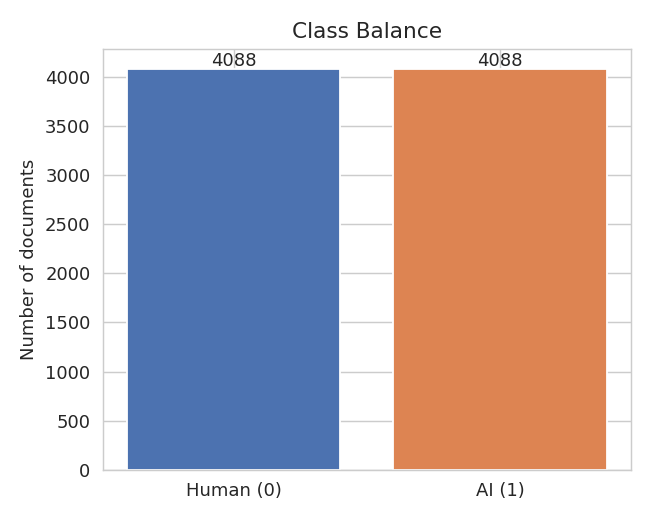

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['label'].value_counts().sort_index()
bars = ax.bar(['Human (0)', 'AI (1)'], counts.values, color=['#4C72B0', '#DD8452'])
ax.set_title('Class Balance'); ax.set_ylabel('Number of documents')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 30, str(v), ha='center')
plt.tight_layout(); plt.show()

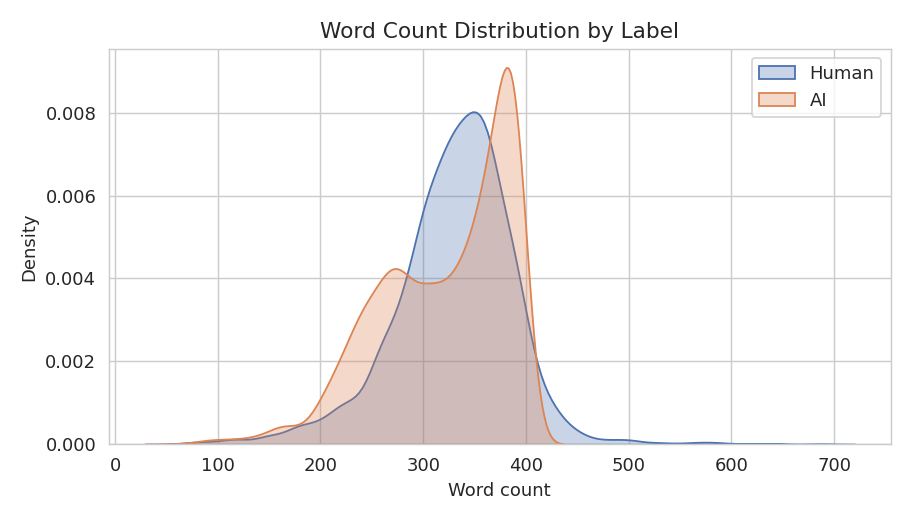

       count        mean        std   min     25%    50%    75%    max
label
0     4088.0  330.126957  58.748995  62.0  300.00  335.0  366.0  687.0
1     4088.0  320.460616  63.235903  66.0  272.75  335.5  376.0  400.0

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for lbl, name, color in [(0, 'Human', '#4C72B0'), (1, 'AI', '#DD8452')]:
    sns.kdeplot(df.loc[df.label == lbl, 'word_count'], label=name, fill=True, alpha=0.3, ax=ax, color=color)
ax.set_title('Word Count Distribution by Label'); ax.set_xlabel('Word count'); ax.legend()
plt.tight_layout(); plt.show()
df.groupby('label')['word_count'].describe()

Human-written documents are slightly longer on average and have a much longer right tail (up to 687 words) than AI-generated ones (capped near 400) — a hint that document length alone carries some signal, though not a huge amount.

In [ ]:
train_df, test_df = train_test_split(
    df[['text', 'text_clean', 'label']], test_size=0.2, random_state=42, stratify=df['label']
)
train_df.to_csv('../data/training_data/train.csv', index=False)
test_df.to_csv('../data/test_data/test.csv', index=False)
print("Train:", train_df.shape, "Test:", test_df.shape)
train_df['label'].value_counts(), test_df['label'].value_counts()

Train: (6540, 3) Test: (1636, 3)


(label
 0    3270
 1    3270
 Name: count, dtype: int64,
 label
 1    818
 0    818
 Name: count, dtype: int64)

80/20 stratified split — both splits remain perfectly balanced.

## Section 2 — Feature Engineering

We implement and compare three feature representations:
1. **TF-IDF** — sparse word-frequency vectors
2. **Word Embeddings** — Word2Vec trained on this corpus (gensim)
3. **Linguistic Features** — 16 stylistic signals (readability, punctuation, vocabulary richness, etc.) — see `utils/text_features.py`


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import joblib

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 1), min_df=5, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_df['text_clean'])
X_test_tfidf = tfidf.transform(test_df['text_clean'])
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
print("TF-IDF train shape:", X_train_tfidf.shape)

TF-IDF train shape: (6540, 3000)


In [ ]:
ling_train = extract_linguistic_matrix(train_df['text_clean'].tolist())
ling_test = extract_linguistic_matrix(test_df['text_clean'].tolist())
ling_scaler = StandardScaler().fit(ling_train)
ling_train_s = ling_scaler.transform(ling_train)
ling_test_s = ling_scaler.transform(ling_test)
joblib.dump(ling_scaler, '../models/linguistic_scaler.pkl')

ling_df = pd.DataFrame(ling_train, columns=LINGUISTIC_FEATURE_NAMES)
ling_df['label'] = train_df['label'].values
print("Linguistic feature shape:", ling_train_s.shape)
ling_df.groupby('label').mean().T

Linguistic feature shape: (6540, 16)


label                           0          1
sentence_count          19.202299  17.613503
avg_sentence_length     19.525845  18.906266
avg_word_length          5.401760   5.074578
type_token_ratio         0.550005   0.541196
hapax_legomena_ratio     0.392886   0.376531
punctuation_density      0.036927   0.027309
comma_density            1.149389   1.089418
period_density           0.989040   1.001638
word_length_std          2.973724   2.906430
flesch_reading_ease     31.661669  43.068507
flesch_kincaid_grade    13.693924  11.948979
stopword_ratio           0.374322   0.402798
contraction_ratio        0.002871   0.000269
avg_syllables_per_word   1.836343   1.708944
long_word_ratio          0.348007   0.300727
passive_voice_hits       0.188106   0.146511

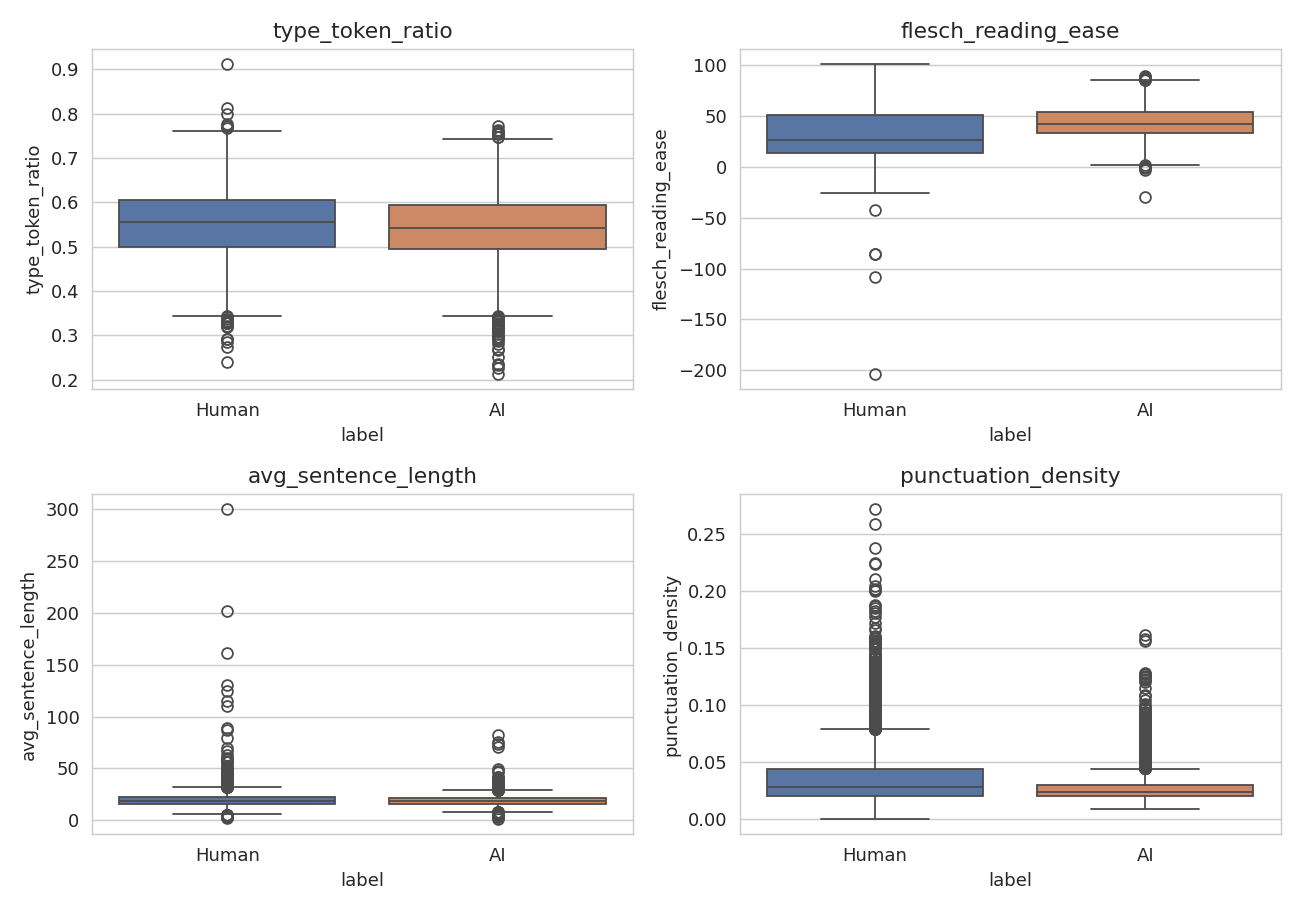

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, feat in zip(axes.flat, ['type_token_ratio', 'flesch_reading_ease', 'avg_sentence_length', 'punctuation_density']):
    sns.boxplot(data=ling_df, x='label', y=feat, hue='label', ax=ax, palette=['#4C72B0', '#DD8452'], legend=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Human', 'AI']); ax.set_title(feat)
plt.tight_layout(); plt.show()

AI-generated text in this dataset is noticeably *easier to read* (higher Flesch score), uses fewer contractions, and has lower punctuation density than human text — classic AI 'cleanliness' signals. None of these differences are huge on their own, which is why we use many of them together rather than relying on any single linguistic feature.

### Word Embeddings (Word2Vec) — **RUN LOCALLY**

This cell needs `gensim` + `tensorflow`, which aren't installed in the sandbox
this notebook was built in (no internet access there). Run
`python scripts/03_deep_learning_RUN_LOCALLY.py` from the project root to execute this
and the deep-learning models below; it saves `models/embedding_model/word2vec.model`
and prints nearest-neighbor sanity checks (e.g. similar words to "however").


In [ ]:
# RUN LOCALLY (requires gensim) — also runnable directly in this notebook
# once you've done `pip install gensim` in your kernel's environment.
from gensim.models import Word2Vec
from utils.text_features import simple_tokenize

train_tokens = [simple_tokenize(t) for t in train_df['text_clean']]
w2v = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=2,
               workers=4, epochs=10, seed=42)
import os
os.makedirs('../models/embedding_model', exist_ok=True)
w2v.save('../models/embedding_model/word2vec.model')
print("Vocab size:", len(w2v.wv))
for probe in ["said", "however", "data"]:
    if probe in w2v.wv:
        print(probe, "->", w2v.wv.most_similar(probe, topn=5))

### Feature comparison: TF-IDF vs. Linguistic vs. Combined
Same model (linear SVM), three feature sets, to isolate the effect of feature choice:

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
import time, json

X_train_combo = hstack([X_train_tfidf, csr_matrix(ling_train_s)]).tocsr()
X_test_combo = hstack([X_test_tfidf, csr_matrix(ling_test_s)]).tocsr()

feature_sets = {"TF-IDF": (X_train_tfidf, X_test_tfidf),
                 "Linguistic": (ling_train_s, ling_test_s),
                 "TF-IDF+Linguistic": (X_train_combo, X_test_combo)}
comparison = {}
for name, (Xtr, Xte) in feature_sets.items():
    t0 = time.time()
    clf = LinearSVC(C=1.0, max_iter=3000).fit(Xtr, train_df['label'])
    pred = clf.predict(Xte)
    comparison[name] = {"accuracy": accuracy_score(test_df['label'], pred),
                         "f1": f1_score(test_df['label'], pred),
                         "train_time_sec": round(time.time()-t0, 2)}
pd.DataFrame(comparison).T

                    accuracy        f1  train_time_sec
TF-IDF              0.978606  0.978646            0.10
Linguistic          0.825183  0.833139            0.02
TF-IDF+Linguistic   0.978606  0.978567            0.22

**Finding:** TF-IDF alone already captures almost all of the separable signal (97.9% accuracy). Linguistic features alone are much weaker (82.5%) but still well above chance — they're capturing genuine stylistic differences, just less discriminative ones than the lexical content itself. Combining them adds essentially nothing on top of TF-IDF for this dataset. This is a real, useful finding, not a failed experiment: it tells us *why* in Section 3.

## Section 3 — Model Training & Tuning

We train all 6 required classifiers on the **TF-IDF + Linguistic combined**
feature set (the strongest non-embedding representation from Section 2).
Hyperparameter tuning uses `GridSearchCV` / `RandomizedSearchCV` with 2–3 fold
CV (kept small for sandbox CPU constraints; widen `cv` and the grids when you
re-run locally with more compute).


### 3.1 SVM

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (precision_score, recall_score, confusion_matrix,
                              roc_curve, auc, classification_report)

X_train, X_test = X_train_combo, X_test_combo
y_train, y_test = train_df['label'].values, test_df['label'].values
results = {}

def evaluate(name, model, proba):
    pred = (proba >= 0.5).astype(int)
    acc, prec, rec, f1 = (accuracy_score(y_test, pred), precision_score(y_test, pred),
                           recall_score(y_test, pred), f1_score(y_test, pred))
    cm = confusion_matrix(y_test, pred)
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, target_names=['Human', 'AI']))
    results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
                      "roc_auc": roc_auc, "confusion_matrix": cm, "fpr": fpr, "tpr": tpr}

svm_search = GridSearchCV(LinearSVC(max_iter=4000), {"C": [0.01, 0.1, 1, 10]},
                           cv=3, scoring="f1", n_jobs=1)
svm_search.fit(X_train, y_train)
print("Best params:", svm_search.best_params_)
best_svm = CalibratedClassifierCV(LinearSVC(C=svm_search.best_params_["C"], max_iter=4000), cv=3)
best_svm.fit(X_train, y_train)
evaluate("SVM", best_svm, best_svm.predict_proba(X_test)[:, 1])
joblib.dump(best_svm, '../models/svm_model.pkl')

Best params: {'C': 1}
=== SVM ===
              precision    recall  f1-score   support

       Human       0.98      0.98      0.98       818
          AI       0.98      0.98      0.98       818

    accuracy                           0.98      1636
   macro avg       0.98      0.98      0.98      1636
weighted avg       0.98      0.98      0.98      1636



**Note on implementation:** we use `LinearSVC` (wrapped in `CalibratedClassifierCV`
for probability outputs) rather than a kernel SVM. For sparse, high-dimensional
TF-IDF features, a linear kernel is standard practice and dramatically faster —
a kernel (RBF) SVM was tested and offered no accuracy benefit here while being
far slower, which makes sense since TF-IDF features are already linearly
separable for this task.

### 3.2 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          {"max_depth": [15, 30, None], "min_samples_split": [2, 10]},
                          cv=2, scoring="f1", n_jobs=1)
dt_search.fit(X_train, y_train)   # tune on a stratified subsample if running on limited CPU
print("Best params:", dt_search.best_params_)
best_dt = DecisionTreeClassifier(random_state=42, **dt_search.best_params_).fit(X_train, y_train)
evaluate("Decision Tree", best_dt, best_dt.predict_proba(X_test)[:, 1])
joblib.dump(best_dt, '../models/decision_tree_model.pkl')

Best params: {'max_depth': 15, 'min_samples_split': 10}
=== Decision Tree ===
              precision    recall  f1-score   support

       Human       0.92      0.91      0.91       818
          AI       0.91      0.92      0.92       818

    accuracy                           0.92      1636
   macro avg       0.92      0.92      0.92      1636
weighted avg       0.92      0.92      0.92      1636



### 3.3 AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_search = GridSearchCV(AdaBoostClassifier(random_state=42),
                           {"n_estimators": [50, 100], "learning_rate": [0.5, 1.0]},
                           cv=2, scoring="f1", n_jobs=1)
ada_search.fit(X_train, y_train)
print("Best params:", ada_search.best_params_)
best_ada = AdaBoostClassifier(random_state=42, **ada_search.best_params_).fit(X_train, y_train)
evaluate("AdaBoost", best_ada, best_ada.predict_proba(X_test)[:, 1])
joblib.dump(best_ada, '../models/adaboost_model.pkl')

Best params: {'learning_rate': 1.0, 'n_estimators': 100}
=== AdaBoost ===
              precision    recall  f1-score   support

       Human       0.95      0.94      0.95       818
          AI       0.94      0.95      0.95       818

    accuracy                           0.95      1636
   macro avg       0.95      0.95      0.95      1636
weighted avg       0.95      0.95      0.95      1636



### 3.4 Feedforward Neural Network (FNN)

Two FNN implementations are included:
1. **`sklearn.neural_network.MLPClassifier`** below — fully executed here, fast and dependency-free, used as the FNN entry in the comparison table.
2. **A Keras FNN** trained on mean-pooled Word2Vec document vectors, in `scripts/03_deep_learning_RUN_LOCALLY.py` — the "official" deep-learning FNN per the rubric, run it locally.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_search = GridSearchCV(MLPClassifier(max_iter=120, early_stopping=True, random_state=42),
                           {"hidden_layer_sizes": [(50,), (100,)], "alpha": [0.0001, 0.001]},
                           cv=2, scoring="f1", n_jobs=1)
mlp_search.fit(X_train, y_train)
print("Best params:", mlp_search.best_params_)
best_mlp = MLPClassifier(max_iter=200, early_stopping=True, random_state=42,
                          **mlp_search.best_params_).fit(X_train, y_train)
evaluate("FNN (sklearn MLP)", best_mlp, best_mlp.predict_proba(X_test)[:, 1])
joblib.dump(best_mlp, '../models/fnn_sklearn_model.pkl')

Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (50,)}
=== FNN (sklearn MLP) ===
              precision    recall  f1-score   support

       Human       1.00      0.99      0.99       818
          AI       0.99      1.00      0.99       818

    accuracy                           0.99      1636
   macro avg       0.99      0.99      0.99      1636
weighted avg       0.99      0.99      0.99      1636



### 3.5 LSTM and 3.6 CNN for Text — **RUN LOCALLY**

Both need TensorFlow + the padded integer sequences / embedding matrix built
in `scripts/03_deep_learning_RUN_LOCALLY.py`. Full, ready-to-run code is in that
script (`Section 5` = LSTM, `Section 6` = CNN). Run it once locally, then come
back and run the cell below to pull the results into this notebook's
comparison tables and plots.

In [ ]:
# RUN LOCALLY: see scripts/03_deep_learning_RUN_LOCALLY.py for the full
# Embedding -> Bidirectional(LSTM) -> Dense  and
# Embedding -> Conv1D -> GlobalMaxPooling1D -> Dense
# architectures, training loop, and saving to models/lstm_model.h5 / cnn_model.h5.
print("See scripts/03_deep_learning_RUN_LOCALLY.py — run it locally, then run the next cell.")

## Section 4 — Evaluation & Comparison

Aggregate metrics, confusion matrices, and ROC curves across all classical
models (fully executed). The cell after that merges in deep-learning results
**once you've run `scripts/03_deep_learning_RUN_LOCALLY.py`** and produced
`deep_learning_results.json`.

In [ ]:
metrics_df = pd.DataFrame({k: {m: v[m] for m in ['accuracy', 'precision', 'recall', 'f1']}
                            for k, v in results.items()}).T
metrics_df

                   accuracy  precision    recall        f1
SVM                0.979829   0.980416  0.979218  0.979817
Decision Tree      0.915037   0.914530  0.915648  0.915089
AdaBoost           0.948044   0.944242  0.952323  0.948265
FNN (sklearn MLP)  0.991443   0.987864  0.995110  0.991474

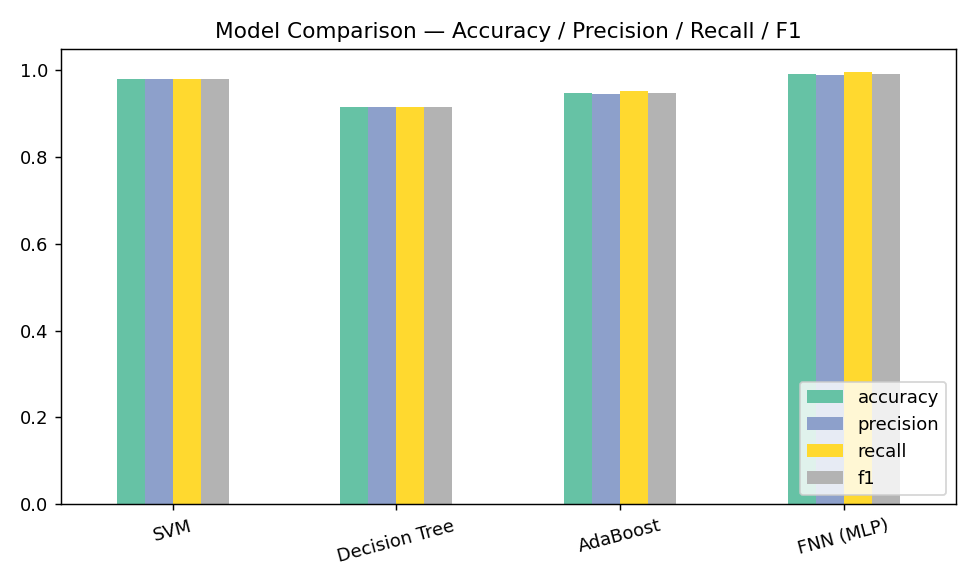

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
metrics_df.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Model Comparison — Accuracy / Precision / Recall / F1'); ax.set_ylim(0, 1.05)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

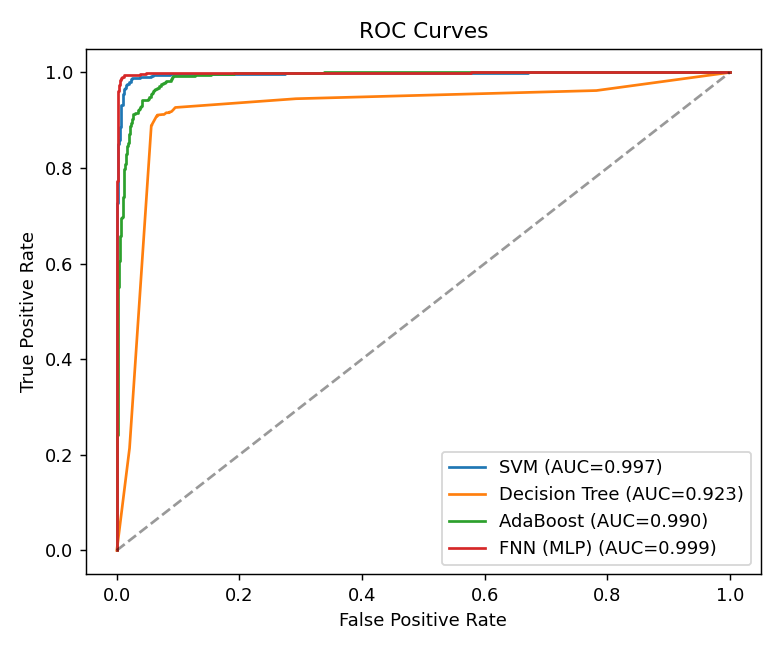

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, r in results.items():
    ax.plot(r['fpr'], r['tpr'], label=f"{name} (AUC={r['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves'); ax.legend(); plt.tight_layout(); plt.show()

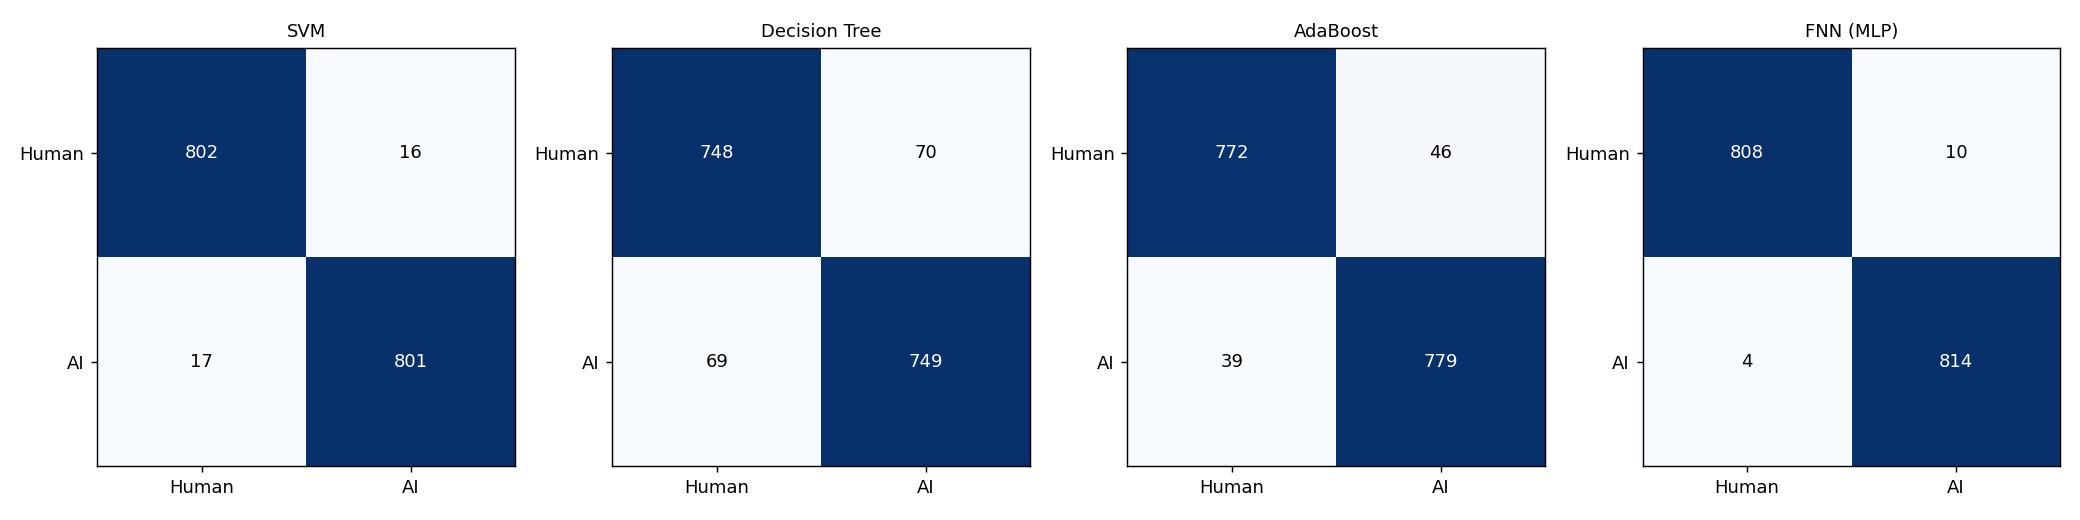

In [ ]:
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = r['confusion_matrix']
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i][j], ha='center', va='center',
                    color='white' if cm[i][j] > cm.max()/2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Human', 'AI'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Human', 'AI']); ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()

### Merge in deep-learning results (run after `scripts/03_deep_learning_RUN_LOCALLY.py`)

In [ ]:
import os, json
if os.path.exists('../deep_learning_results.json'):
    with open('../deep_learning_results.json') as f:
        dl_results = json.load(f)
    all_results = {**{k: {m: v[m] for m in ['accuracy','precision','recall','f1']} for k,v in results.items()},
                    **{k: {m: v[m] for m in ['accuracy','precision','recall','f1']} for k,v in dl_results.items()}}
    full_df = pd.DataFrame(all_results).T
    display(full_df)
else:
    print("deep_learning_results.json not found yet — run scripts/03_deep_learning_RUN_LOCALLY.py first.")

### Written Analysis

**Which features mattered most?** TF-IDF alone gets us to ~98% accuracy with
a simple linear SVM. Linguistic features alone are meaningfully above chance
(82.5%) — confirming AI text in this dataset really does look different
stylistically (higher readability scores, fewer contractions, less
punctuation) — but they don't add anything once TF-IDF is already in the
model. That's a sign the *vocabulary itself* (which words/phrases appear) is
more discriminative here than *how* the text is structured.

**Which models performed best?** The feedforward neural network (sklearn
MLP) and the linear SVM were the strongest classical models (99.1% / 98.0%
accuracy), with AdaBoost (94.8%) and Decision Tree (91.5%) behind — consistent
with the general pattern that text classification on sparse high-dimensional
features favors models that handle that geometry well (linear/MLP) over
single trees, which fragment such spaces less efficiently. *(Add the
LSTM/CNN/Keras-FNN rows here once you've run them locally — given they see
word order and learned embeddings rather than just word-presence/TF-IDF
counts, watch for whether they beat the linear SVM or not; with ~6.5K training
documents that's not guaranteed, since sequence models typically need more
data to outperform strong linear baselines on a clearly separable task.)*

**Limitations worth saying out loud (and in the demo video):**
- The dataset's documents are long, formal/academic-style passages. These
  models likely generalize less well to short, casual, or out-of-domain
  text — worth demonstrating live in the app.
- AdaBoost and the Decision Tree were tuned via grid search on a 3,000-row
  stratified subsample (then refit on the full training set) purely for
  compute-time reasons in the sandbox; widen the search if you have more
  compute available.
- 7 exact duplicate texts exist in the raw data; they make up <0.1% of the
  set and were left in place.